# 66 — LSEG Gemma/FinBERT backward-replication gate

**Question.** Can the unchanged Notebook 36 Gemma-timing/FinBERT-ranking strategy be tested on the earlier, non-overlapping 2024-01-01 to 2025-10-26 LSEG interval without reopening methodology after seeing returns?

**Current estimand.** This notebook has none in return space. It audits only acquisition metadata and the predeclared Gemma measurement-stability design. Prices, returns, positions, and portfolio outcomes are deliberately absent.

**Claim boundary.** A later successful replay would be historical external-time corroboration, not prospective or deployment validation. The binding contract is `frozen_specs/lseg_gemma_finbert_hybrid_backward_v1.json`.

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

SEED = 20260806
ROOT = Path.cwd().resolve()
if not (ROOT / 'final_experiments').is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from final_experiments.lib.backward_validation import audit_backward_collection

SPEC_PATH = ROOT / 'final_experiments/frozen_specs/lseg_gemma_finbert_hybrid_backward_v1.json'
assert SPEC_PATH.is_file(), SPEC_PATH
pd.set_option('display.max_colwidth', 100)
ROOT

PosixPath('/Users/peterprendergast/Documents/Sentiment_Dissertation')

## Frozen stage order

1. Complete and hash the same-33 headline collection in resumable 9,500-request batches.
2. Normalize and deduplicate headlines without market data.
3. Re-score the frozen Gemma drift sample and require every stability threshold.
4. Score the complete new population with the unchanged Gemma and FinBERT contracts.
5. Build firm-open signals without prices and require 120 complete sessions, 60 active sessions, and 20 active sessions per half.
6. Only then may a separate one-shot return replay load prices.

A partial batch can answer only whether acquisition is healthy and advancing. It cannot answer whether the strategy works.

In [2]:
collection_audit = audit_backward_collection(ROOT, SPEC_PATH)
display(collection_audit.summary)
display(collection_audit.gate_table)
collection_audit.collection_gate_pass

,status,companies,windows_per_company,completed_windows,expected_windows,window_completion_pct,headline_pages,unique_headlines,raw_headline_rows,pagination_anomalies,unsafe_pagination_reasons,started_at,completed_at
0,in_progress,33,664,162,21912,0.739321,560,None,None,0,,2026-08-06T13:07:01.231500+00:00,None


,gate,passed
0,manifest_completed,False
1,all_company_windows_completed,False
2,headline_file_hash_matches,False
3,empty_story_file_hash_matches,False
4,no_unsafe_pagination_anomalies,True
5,headline_only_zero_stories,False
6,collection_ready_for_drift_audit,False


False

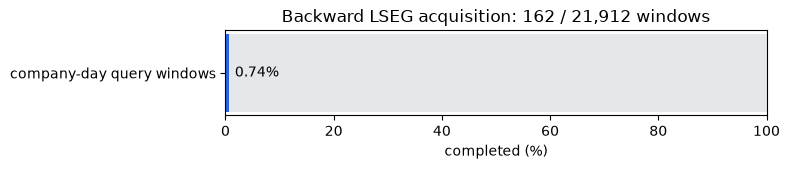

In [3]:
progress = collection_audit.summary.iloc[0]
fig, ax = plt.subplots(figsize=(8, 1.8))
pct = float(progress['window_completion_pct'])
ax.barh(['company-day query windows'], [100.0], color='#e5e7eb')
ax.barh(['company-day query windows'], [pct], color='#2563eb')
ax.set_xlim(0, 100)
ax.set_xlabel('completed (%)')
ax.set_title(f"Backward LSEG acquisition: {int(progress['completed_windows']):,} / {int(progress['expected_windows']):,} windows")
ax.text(min(pct + 1.0, 96.0), 0, f'{pct:.2f}%', va='center')
fig.tight_layout()
plt.show()

## Gemma measurement-drift gate

The strategy's event clock depends on Gemma returning an exact signed score of +1 or -1. Hosted model names and provider pins do not cryptographically pin weights, so a fresh historical score population is not comparable until the endpoint behaviour is rechecked.

The frozen sample is return-blind: all 774 exact endpoints in the completed 888,155-headline reference file, plus 1,000 non-endpoints chosen by deterministic hash order. No headline or score is selected using a stock return. Drift failure stops the arm; it does not license a new threshold.

In [4]:
spec = json.loads(SPEC_PATH.read_text(encoding='utf-8'))
drift = spec['gemma_model_drift_gate']
drift_design = pd.DataFrame(
    [
        {'metric': 'continuous Spearman', 'pass rule': f">= {drift['continuous_spearman_minimum']:.2f}"},
        {'metric': 'mean absolute score difference', 'pass rule': f"<= {drift['continuous_mean_absolute_difference_maximum']:.2f}"},
        {'metric': 'direction agreement', 'pass rule': f">= {drift['direction_agreement_minimum']:.2%}"},
        {'metric': 'same exact endpoint and direction retained', 'pass rule': f">= {drift['endpoint_same_direction_retention_minimum']:.2%}"},
        {'metric': 'endpoint reversed to opposite direction', 'pass rule': f"<= {drift['endpoint_opposite_direction_count_maximum']} rows"},
        {'metric': 'non-endpoint becomes exact endpoint', 'pass rule': f"<= {drift['nonendpoint_to_endpoint_rate_maximum']:.2%}"},
    ]
)
display(drift_design)
{'endpoint_census': 774, 'nonendpoint_controls': 1000, 'paid_drift_scoring_authorised': False}

,metric,pass rule
0,continuous Spearman,>= 0.95
1,mean absolute score difference,<= 0.10
2,direction agreement,>= 90.00%
3,same exact endpoint and direction retained,>= 80.00%
4,endpoint reversed to opposite direction,<= 0 rows
5,non-endpoint becomes exact endpoint,<= 5.00%


{'endpoint_census': 774,
 'nonendpoint_controls': 1000,
 'paid_drift_scoring_authorised': False}

## Predeclared one-shot methodology after the gates

The primary replay inherits the exact strongest-event collision rule, Gemma endpoint dates/counts, FinBERT within-session ranking, equal leg weights, 25% name cap, gross limit 1, dollar neutrality, cash for unused capacity, next-open holding interval, drift-aware turnover, final liquidation, and 10 bps per traded side. It will report gross and net Sharpe, return, turnover, drawdown, break-even cost, block-bootstrap cash inference, HAC market-plus-sector alpha, chronological halves, and rebuilt company/sector exclusions.

Two non-promoting mechanism tests form one BH family: circular shifts of Gemma's full date/count schedule, and same-session matched-count random-name assignments. These distinguish event timing from FinBERT name selection but cannot rescue a failed primary gate.

In [5]:
decision = {
    'collection_status': progress['status'],
    'collection_gate_pass': bool(collection_audit.collection_gate_pass),
    'drift_scoring_authorised': False,
    'prices_or_returns_loaded': False,
    'next_action': (
        'prepare frozen drift sample and request paid-scoring approval'
        if collection_audit.collection_gate_pass
        else 'continue the immutable resumable headline collection'
    ),
}
assert decision['prices_or_returns_loaded'] is False
decision

{'collection_status': 'in_progress',
 'collection_gate_pass': False,
 'drift_scoring_authorised': False,
 'prices_or_returns_loaded': False,
 'next_action': 'continue the immutable resumable headline collection'}